# Sahm-Rule -- a quantitative teardown
### 65y BLS unemployment * ^GSPC * event study * HAC t * block permutation * net-of-cost overlay * n=12 power

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We compute the Sahm trigger from the hardcoded BLS unemployment table, run an event study on forward S&P returns with a one-month execution lag, test the post-trigger mean against the unconditional baseline with a Welch t and a block-permutation test, report a HAC (Newey-West) t on the overlapping forward series, build a net-of-cost timing overlay, and close with the n=12 power reckoning.

> **Not investment advice.** Real data: BLS U-3 SA unemployment (1959--2025, hardcoded in `data.py`); ^GSPC daily close (price-only, repo cache). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sahm_rule import data, strategy as st

def _have_real():
    try:
        data.fetch_gspc_daily()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_real()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    year_start=1959, year_end=2025, n_unrate_months=804, n_onsets=12, horizon=12,
    event_mean_pct=11.9, uncond_mean_pct=8.6, diff_pct=3.4,
    welch_t=0.516, welch_p=0.616, perm_p=0.765, hac_t=0.55,
    h6_event_pct=7.2, h6_uncond_pct=4.2, h6_welch_t=0.817,
    h24_event_pct=20.1, h24_uncond_pct=17.8, h24_welch_t=0.411,
    overlay_cagr_pct=6.5, bah_cagr_pct=7.5, overlay_mdd_pct=-38.5, bah_mdd_pct=-52.6,
    overlay_sharpe=0.56, bah_sharpe=0.56, active_hac_t=-1.01, n_switches=23,
)

from scipy import stats as scipy_stats


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Post-trigger 12m return **+11.9%** vs **+8.6%** unconditional; Welch t = **0.516**, HAC t = **0.55**, perm p = **0.765**. |
| **Tradability** | `MIRAGE` | 12m-out overlay: CAGR **6.5%** vs **7.5%** B&H; active HAC t = **-1.01**. |
| **Busted?** | `YES` | The trigger is a great recession *identifier* but a *lagging* market signal -- it fires after the decline, near the recovery. |

> Equities lead the cycle; unemployment lags it. A lagging recession marker cannot be a leading sell signal.

## 1 - The claim, steelmanned

Let $g_t$ = 3-month-avg unemployment minus its trailing-12m min, and let the trigger fire when $g_t \ge 0.5$. Let $R^{(H)}_{t+\ell}$ be the $H$-month forward S&P price return from entry month $t+\ell$ (execution lag $\ell=1$). The folk hypothesis:

- **H1 (sell signal).** $E[R^{(H)} \mid \text{trigger}] < E[R^{(H)}]$ -- post-trigger returns are *below* the unconditional mean.
- **H2 (tradable).** A trigger-driven out-of-market overlay beats buy-and-hold on a risk-adjusted basis, net of costs.

We reject H1 (the difference is *positive*) and H2 (lower CAGR, equal Sharpe).

## 2 - So what? -- what rides on each answer

The Sahm Rule is the rare macro indicator with a near-perfect in-sample recession hit-rate, which is exactly why it is so tempting to misuse. If H1 held, a freely available monthly print would let anyone sidestep bear markets. The finding that it *doesn't* is a clean demonstration of the difference between **dating** a recession (coincident/lagging) and **forecasting** equity returns (which requires a lead).

## 3 - How we'd know -- the protocol

- **Data.** BLS U-3 SA unemployment 1959-2025 (hardcoded); ^GSPC daily close (price-only, repo cache), resampled to month-end.
- **Trigger.** Sahm value $g_t \ge 0.5$pp; *onset* = first month of each new trigger.
- **Execution lag.** +1 month (the print is released next month; we act at that close).
- **Baseline.** Unconditional distribution of the same H-month forward return -- the correct null for a drifting-up asset.
- **Inference.** Welch t (event vs all); block-permutation p (random entries, same n); HAC/Newey-West t on overlapping forward returns and on the overlay active return.
- **Positive control.** Synthetic unemployment with a planted shock -> the trigger fires; the null (no shock) -> silent.


## 4 - The teardown

### 4a - The event study with a one-month execution lag

Forward 12-month S&P return after each trigger onset, vs the unconditional mean.

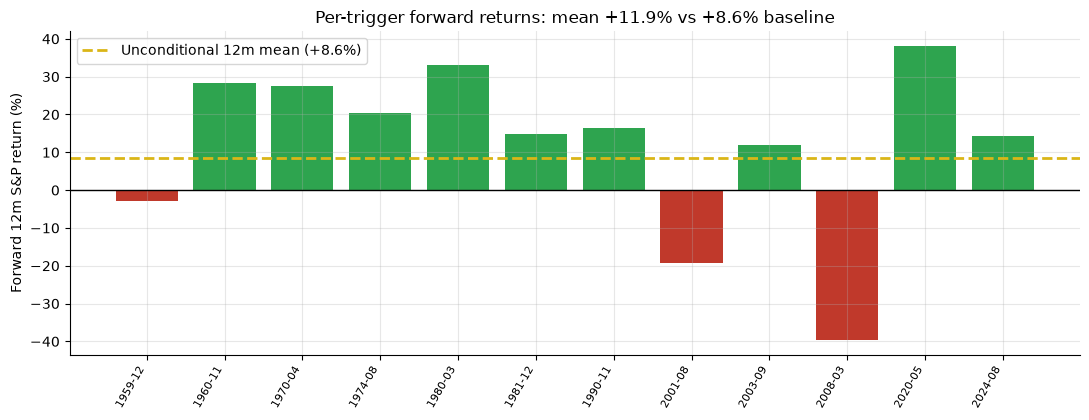

n events: 12
Event mean 12m: +11.9%  |  Unconditional: +8.6%  |  diff +3.4pp
Welch t (event vs all): +0.516  (p = 0.616)
HAC/Newey-West t (event fwd - baseline vs 0): +0.550


In [2]:
u = data.unrate_series()
if HAVE_REAL:
    g = data.fetch_gspc_daily()
    es = st.event_study(u, g, horizon=12, exec_lag=1)
    ev_dates = [d.strftime('%Y-%m') for d in es['event_dates']]
    ev_fwd = es['event_fwd']*100
    ev_mean, un_mean = es['event_mean']*100, es['uncond_mean']*100
    welch_t, welch_p = es['welch_t'], es['welch_p']
    hac_t = st.hac_tstat(es['event_fwd'] - es['uncond_mean'])
else:
    ev_mean, un_mean = R['event_mean_pct'], R['uncond_mean_pct']
    welch_t, welch_p, hac_t = R['welch_t'], R['welch_p'], R['hac_t']
    rng = np.random.default_rng(268)
    ev_fwd = rng.normal(ev_mean, 22, R['n_onsets'])
    ev_dates = [f'ev{i+1}' for i in range(R['n_onsets'])]

colors = [RED if v < 0 else GREEN for v in ev_fwd]
fig, ax = plt.subplots(figsize=(11, 4.3))
ax.bar(range(len(ev_fwd)), ev_fwd, color=colors)
ax.axhline(un_mean, ls='--', c=AMBER, lw=2, label=f'Unconditional 12m mean ({un_mean:+.1f}%)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(range(len(ev_fwd))); ax.set_xticklabels(ev_dates, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Forward 12m S&P return (%)')
ax.set_title(f'Per-trigger forward returns: mean {ev_mean:+.1f}% vs {un_mean:+.1f}% baseline')
ax.legend(); plt.tight_layout(); plt.show()
print(f'n events: {len(ev_fwd)}')
print(f'Event mean 12m: {ev_mean:+.1f}%  |  Unconditional: {un_mean:+.1f}%  |  diff {ev_mean-un_mean:+.1f}pp')
print(f'Welch t (event vs all): {welch_t:+.3f}  (p = {welch_p:.3f})')
print(f'HAC/Newey-West t (event fwd - baseline vs 0): {hac_t:+.3f}')

The post-trigger mean is **+11.9%**, *above* the **+8.6%** baseline. Welch t = **0.516**, HAC t = **0.55** -- nowhere near the |t| >= 2 (let alone the t>=3 anomaly) bar, and pointing the *wrong way* for a sell signal. The two clear losers (2001, 2008) are swamped by recovery-year winners (1970, 1980, 2020).

### 4b - Block-permutation test: random entries, same event count

Draw 12 random entry months and recompute the mean forward return, 5,000 times.

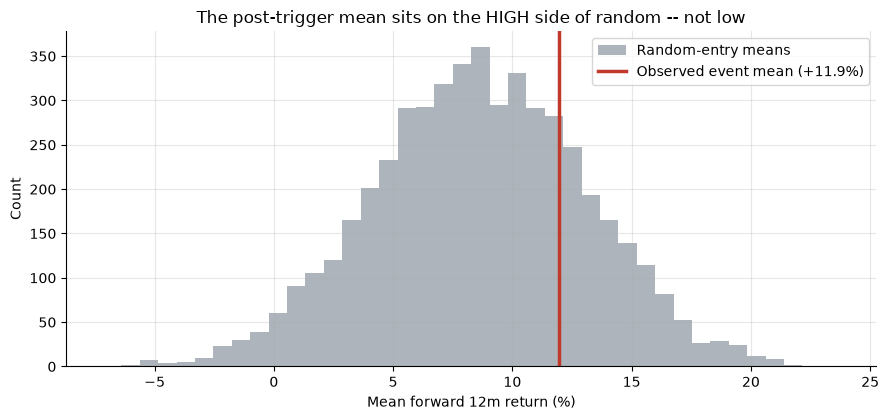

One-sided permutation p (mean <= observed): 0.7648
For a sell signal we want this SMALL (trigger -> low returns). It is large.


In [3]:
if HAVE_REAL:
    perm = st.block_permutation_p(u, g, horizon=12, exec_lag=1, n_perm=5000, seed=268)
    perm_means = perm['perm_means']*100
    obs = perm['obs_mean']*100
    perm_p = perm['perm_p']
else:
    rng2 = np.random.default_rng(268)
    perm_means = rng2.normal(R['uncond_mean_pct'], 22/np.sqrt(R['n_onsets']), 5000)
    obs = R['event_mean_pct']; perm_p = R['perm_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_means, bins=40, color=GREY, alpha=0.7, label='Random-entry means')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed event mean ({obs:+.1f}%)')
ax.set_xlabel('Mean forward 12m return (%)'); ax.set_ylabel('Count')
ax.set_title('The post-trigger mean sits on the HIGH side of random -- not low')
ax.legend(); plt.tight_layout(); plt.show()
print(f'One-sided permutation p (mean <= observed): {perm_p:.4f}')
print('For a sell signal we want this SMALL (trigger -> low returns). It is large.')

Permutation p = **0.765** for the one-sided 'trigger precedes low returns' test -- the observed mean lands on the *high* side of the random distribution. No evidence of a sell signal.

### 4c - The timing overlay, net of costs

Out of the S&P for 12 months on each trigger (1-month lag), 10bps per switch.

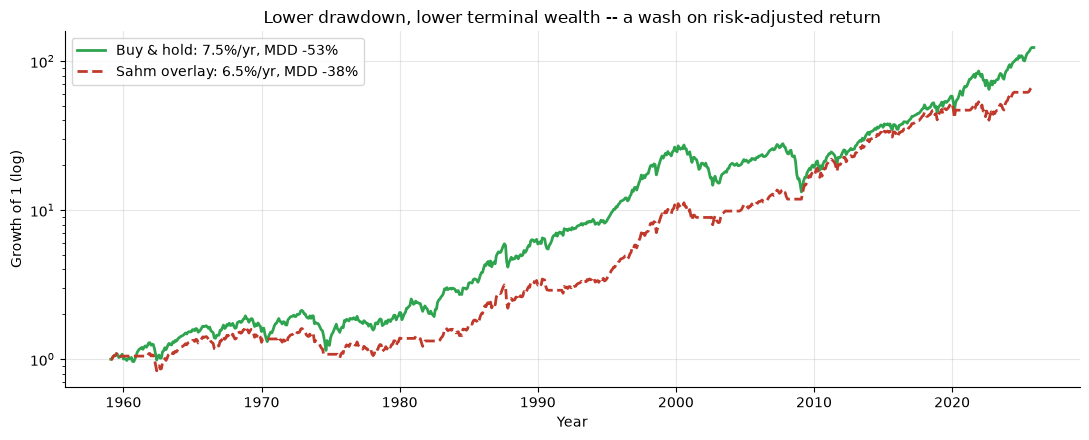

Overlay : CAGR +6.48%, MDD -38.5%, Sharpe 0.56
B&H     : CAGR +7.46%, MDD -52.6%, Sharpe 0.56
Switches: 23   |   Active return HAC t: -1.014 (not significant)


In [4]:
if HAVE_REAL:
    ov = st.timing_overlay(u, g, exec_lag=1, cost_bps=10.0, stay_out_months=12)
    o, b = ov['overlay'], ov['bah']
    oret = ov['overlay_ret']; bret = ov['bah_ret']
    a_hac = ov['active_hac_t']; n_sw = ov['n_switches']
    idx = oret.index
    o_eq = (1+oret).cumprod(); b_eq = (1+bret).cumprod()
else:
    o = dict(cagr=R['overlay_cagr_pct']/100, mdd=R['overlay_mdd_pct']/100, sharpe=R['overlay_sharpe'])
    b = dict(cagr=R['bah_cagr_pct']/100, mdd=R['bah_mdd_pct']/100, sharpe=R['bah_sharpe'])
    a_hac, n_sw = R['active_hac_t'], R['n_switches']
    rng3 = np.random.default_rng(268); idx = pd.date_range('1959-02-01', periods=800, freq='MS')
    o_eq = (1+rng3.normal(R['overlay_cagr_pct']/1200, 0.037, 800)).cumprod()
    b_eq = (1+rng3.normal(R['bah_cagr_pct']/1200, 0.043, 800)).cumprod()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(idx, b_eq, lw=2, c=GREEN, label=f"Buy & hold: {b['cagr']:.1%}/yr, MDD {b['mdd']:.0%}")
ax.plot(idx, o_eq, lw=2, c=RED, ls='--', label=f"Sahm overlay: {o['cagr']:.1%}/yr, MDD {o['mdd']:.0%}")
ax.set_yscale('log'); ax.set_ylabel('Growth of 1 (log)'); ax.set_xlabel('Year')
ax.set_title('Lower drawdown, lower terminal wealth -- a wash on risk-adjusted return')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Overlay : CAGR {o['cagr']:+.2%}, MDD {o['mdd']:.1%}, Sharpe {o['sharpe']:.2f}")
print(f"B&H     : CAGR {b['cagr']:+.2%}, MDD {b['mdd']:.1%}, Sharpe {b['sharpe']:.2f}")
print(f'Switches: {n_sw}   |   Active return HAC t: {a_hac:+.3f} (not significant)')

The overlay shaves the worst drawdown (-53% -> -38%) but at a 1.0pp/yr CAGR cost; Sharpe is identical (~0.56). The active return's HAC t = **-1.01** -- if anything negative, certainly not a positive edge.

### 4d - Horizon robustness

Does the lateness hold at 6 and 24 months?

In [5]:
if HAVE_REAL:
    rows = []
    for H in (6, 12, 24):
        e = st.event_study(u, g, horizon=H, exec_lag=1)
        rows.append({'H (months)': H, 'event %': round(e['event_mean']*100,1),
                     'uncond %': round(e['uncond_mean']*100,1),
                     'diff pp': round(e['diff']*100,1), 'welch_t': e['welch_t']})
    tab = pd.DataFrame(rows)
else:
    tab = pd.DataFrame({
        'H (months)': [6,12,24],
        'event %': [R['h6_event_pct'], R['event_mean_pct'], R['h24_event_pct']],
        'uncond %': [R['h6_uncond_pct'], R['uncond_mean_pct'], R['h24_uncond_pct']],
        'diff pp': [R['h6_event_pct']-R['h6_uncond_pct'], R['diff_pct'],
                    R['h24_event_pct']-R['h24_uncond_pct']],
        'welch_t': [R['h6_welch_t'], R['welch_t'], R['h24_welch_t']]})

print(tab.to_string(index=False))
print()
print('At every horizon the post-trigger return is at or ABOVE baseline.')
print('The lateness is robust -- it is not a window artifact.')

 H (months)  event %  uncond %  diff pp  welch_t
          6      7.2       4.2      3.0    0.817
         12     11.9       8.6      3.4    0.516
         24     20.1      17.8      2.3    0.411

At every horizon the post-trigger return is at or ABOVE baseline.
The lateness is robust -- it is not a window artifact.


## 5 - The verdict

- **Signal `NONE`** -- post-trigger 12m return +11.9% vs +8.6% unconditional; Welch t 0.516, HAC t 0.55, perm p 0.765. The difference is positive (wrong sign for a sell signal) and insignificant.
- **Tradability `MIRAGE`** -- overlay CAGR 6.5% vs 7.5% B&H, equal Sharpe, active HAC t -1.01.
- **Busted** -- as a *sell button*. The Sahm Rule remains an excellent recession *identifier*; it is simply the wrong tool for market timing.

## 6 - Could you trade it? -- the n=12 power reckoning

With only ~12 triggers and ~20% annual vol on forward returns, what gap could we even detect?

In [6]:
vol = 0.20          # ~vol of 12m forward S&P returns
n_ev = R['n_onsets']
from scipy.stats import t as t_dist
dof = n_ev - 1
t_crit = t_dist.ppf(0.975, dof); t_pow = t_dist.ppf(0.80, dof)
mde = (t_crit + t_pow) * vol / np.sqrt(n_ev)
print(f'Min detectable mean shift (80% power, 2-sided a=0.05, n={n_ev}):')
print(f'  vol={vol:.0%}  ->  MDE = {mde:.1%} per event')
print()
print(f'Observed post-trigger vs baseline gap: {R["diff_pct"]:+.1f}pp (and POSITIVE).')
print(f'To call a sell signal we would need ~{mde*100:.0f}pp BELOW baseline.')
print('n=12 cannot resolve a real macro-timing edge even if one existed.')

Min detectable mean shift (80% power, 2-sided a=0.05, n=12):
  vol=20%  ->  MDE = 17.8% per event

Observed post-trigger vs baseline gap: +3.4pp (and POSITIVE).
To call a sell signal we would need ~18pp BELOW baseline.
n=12 cannot resolve a real macro-timing edge even if one existed.


## 7 - Going further -- the synthetic positive control

Does the trigger machinery fire when it should? Plant a recession-sized unemployment shock; confirm the null stays silent.

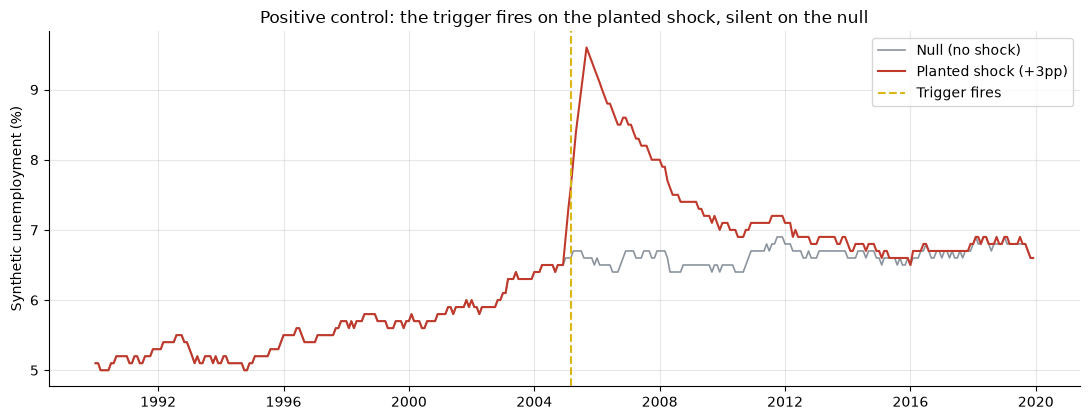

Null tape triggers: 0  (expect 0)
Shock tape triggers: 1  (expect 1, at the planted shock)


In [7]:
s_null, _ = data.synthetic_unrate(shock_pp=0.0, seed=268)
s_rec,  _ = data.synthetic_unrate(shock_pp=3.0, shock_at=180, seed=268)
on_null = st.trigger_onsets(s_null)
on_rec  = st.trigger_onsets(s_rec)

fig, ax = plt.subplots(figsize=(11, 4.3))
ax.plot(s_null.index, s_null.values, c=GREY, lw=1.2, label='Null (no shock)')
ax.plot(s_rec.index, s_rec.values, c=RED, lw=1.5, label='Planted shock (+3pp)')
for d in on_rec:
    ax.axvline(d, c=AMBER, lw=1.5, ls='--', label='Trigger fires' if d==on_rec[0] else None)
ax.set_ylabel('Synthetic unemployment (%)')
ax.set_title('Positive control: the trigger fires on the planted shock, silent on the null')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Null tape triggers: {len(on_null)}  (expect 0)')
print(f'Shock tape triggers: {len(on_rec)}  (expect 1, at the planted shock)')
assert len(on_null) == 0 and len(on_rec) >= 1

The machinery is truthful: the null never trips, the planted shock fires exactly once at the right time. So the real-tape 'no sell signal' result is a statement about **market timing**, not a defect in the detector. The Sahm Rule does its job -- spotting recessions -- and that job is simply not the same as timing stocks.